In [ ]:
# load the data and models:
from pathlib import Path
import pandas as pd
import numpy as np
import joblib
import time

DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
RESULTS_DIR = Path("../results/metrics")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

X_test = pd.read_csv(DATA_DIR / "X_test_processed.csv")
y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze("columns")

rf_model = joblib.load(MODELS_DIR / "random_forest.pkl")
lgbm_model = joblib.load(MODELS_DIR / "lightgbm.pkl")
xgb_model = joblib.load(MODELS_DIR / "xgboost.pkl")

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (118108, 421)
y_test: (118108,)


In [2]:
# Use a small representative sample for explanation analysis because SHAP on the full test set will be too slow

sample_size = 500

X_explain = X_test.sample(n=sample_size, random_state=42)
y_explain = y_test.loc[X_explain.index]

print("Explanation sample shape:", X_explain.shape)
print("Fraud cases in sample:", y_explain.sum())

Explanation sample shape: (500, 421)
Fraud cases in sample: 14


In [4]:
# LightGBM SHAP explanation timing

import shap

start_time = time.time()

lgbm_explainer = shap.TreeExplainer(lgbm_model)
lgbm_shap_values = lgbm_explainer.shap_values(X_explain)

lgbm_explanation_time = time.time() - start_time

print(f"LightGBM SHAP explanation time: {lgbm_explanation_time:.4f} seconds")

Matplotlib is building the font cache; this may take a moment.


LightGBM SHAP explanation time: 3.3963 seconds


/Users/user/Documents/trustlens/venv312/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [5]:
# XGBoost SHAP explanation timing

start_time = time.time()

xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(X_explain)

xgb_explanation_time = time.time() - start_time

print(f"XGBoost SHAP explanation time: {xgb_explanation_time:.4f} seconds")

XGBoost SHAP explanation time: 0.8818 seconds


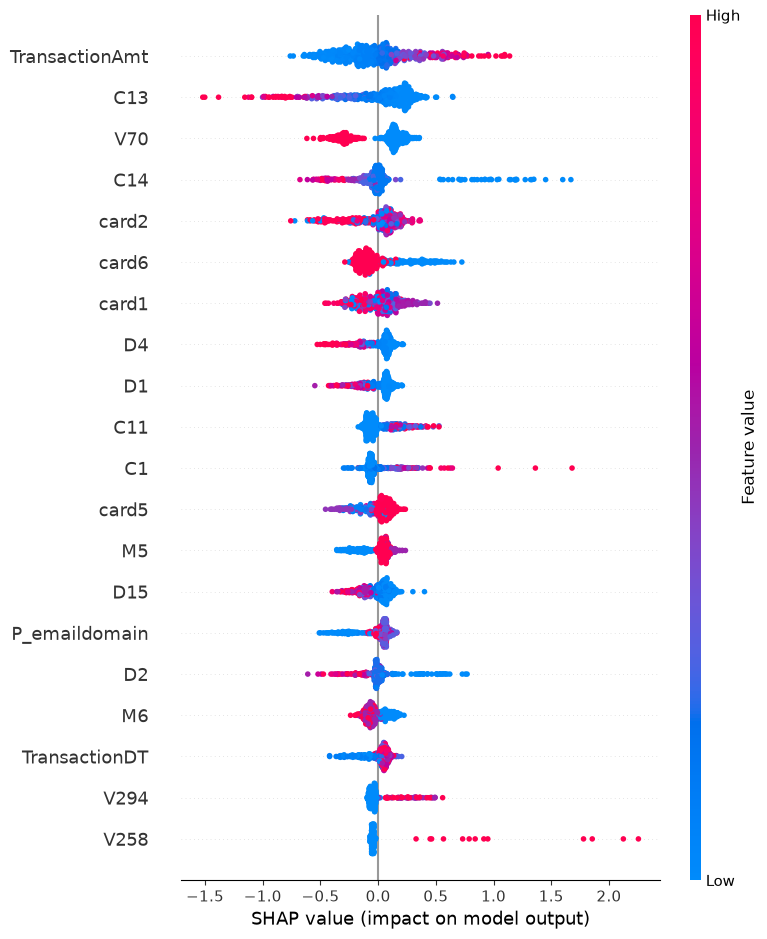

In [6]:
import shap
import matplotlib.pyplot as plt

# Handle SHAP output for binary classifiers
if isinstance(lgbm_shap_values, list):
    shap_values_to_plot = lgbm_shap_values[1]
else:
    shap_values_to_plot = lgbm_shap_values

plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values_to_plot,
    X_explain,
    show=False
)

plt.tight_layout()
plt.savefig("../results/figures/lgbm_shap_summary.png", dpi=300)

plt.show()

In [7]:
start_time = time.time()

rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_explain)

rf_explanation_time = time.time() - start_time

print(f"Random Forest SHAP explanation time: {rf_explanation_time:.4f} seconds")

Random Forest SHAP explanation time: 27.5736 seconds


In [8]:
explanation_times = pd.DataFrame([
    {
        "model": "Random Forest",
        "shap_explanation_time_500_samples": rf_explanation_time
    },
    {
        "model": "LightGBM",
        "shap_explanation_time_500_samples": lgbm_explanation_time
    },
    {
        "model": "XGBoost",
        "shap_explanation_time_500_samples": xgb_explanation_time
    }
])

explanation_times.to_csv(
    RESULTS_DIR / "shap_explanation_times.csv",
    index=False
)

explanation_times

,model,shap_explanation_time_500_samples
0,Random Forest,27.573582
1,LightGBM,3.396310
2,XGBoost,0.881750


In [9]:
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("../results/metrics")

model_results = pd.read_csv(RESULTS_DIR / "model_results_final.csv")

explanation_times = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "interpretation_method": "Model Coefficients",
        "shap_explanation_time_500_samples": "N/A (intrinsic)"
    },
    {
        "model": "Random Forest",
        "interpretation_method": "SHAP",
        "shap_explanation_time_500_samples": 27.5736
    },
    {
        "model": "LightGBM",
        "interpretation_method": "SHAP",
        "shap_explanation_time_500_samples": 3.3963
    },
    {
        "model": "XGBoost",
        "interpretation_method": "SHAP",
        "shap_explanation_time_500_samples": 0.8818
    }
])

comparison_table = model_results.merge(
    explanation_times,
    on="model",
    how="left"
)

comparison_table = comparison_table[
    [
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
        "training_time_seconds",
        "prediction_time_seconds",
        "interpretation_method",
        "shap_explanation_time_500_samples"
    ]
]

comparison_table.to_csv(
    RESULTS_DIR / "trustlens_model_comparison_table.csv",
    index=False
)

comparison_table

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,training_time_seconds,prediction_time_seconds,interpretation_method,shap_explanation_time_500_samples
0,Logistic Regression,0.729874,0.079520,0.635374,0.141350,0.749713,0.129822,257.909931,0.958090,Model Coefficients,N/A (intrinsic)
1,Random Forest,0.897297,0.216237,0.737237,0.334394,0.898557,0.560873,75.424874,1.462579,SHAP,27.5736
2,LightGBM,0.923782,0.294574,0.844665,0.436812,0.954520,0.720850,45.743817,2.636820,SHAP,3.3963
3,XGBoost,0.906509,0.247423,0.818776,0.380011,0.937409,0.655553,87.771222,0.749893,SHAP,0.8818


In [10]:
import pandas as pd
import numpy as np
from pathlib import Path

RESULTS_DIR = Path("../results/metrics")

model_results = pd.read_csv(RESULTS_DIR / "model_results_final.csv")

explanation_times = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "interpretation_method": "Model Coefficients",
        "shap_explanation_time_500_samples": np.nan
    },
    {
        "model": "Random Forest",
        "interpretation_method": "SHAP",
        "shap_explanation_time_500_samples": rf_explanation_time
    },
    {
        "model": "LightGBM",
        "interpretation_method": "SHAP",
        "shap_explanation_time_500_samples": lgbm_explanation_time
    },
    {
        "model": "XGBoost",
        "interpretation_method": "SHAP",
        "shap_explanation_time_500_samples": xgb_explanation_time
    }
])

comparison_table = model_results.merge(
    explanation_times,
    on="model",
    how="left"
)

comparison_table = comparison_table[
    [
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
        "training_time_seconds",
        "prediction_time_seconds",
        "interpretation_method",
        "shap_explanation_time_500_samples"
    ]
]

comparison_table.to_csv(
    RESULTS_DIR / "trustlens_model_comparison_table.csv",
    index=False
)

comparison_table

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,training_time_seconds,prediction_time_seconds,interpretation_method,shap_explanation_time_500_samples
0,Logistic Regression,0.729874,0.079520,0.635374,0.141350,0.749713,0.129822,257.909931,0.958090,Model Coefficients,NaN
1,Random Forest,0.897297,0.216237,0.737237,0.334394,0.898557,0.560873,75.424874,1.462579,SHAP,27.573582
2,LightGBM,0.923782,0.294574,0.844665,0.436812,0.954520,0.720850,45.743817,2.636820,SHAP,3.396310
3,XGBoost,0.906509,0.247423,0.818776,0.380011,0.937409,0.655553,87.771222,0.749893,SHAP,0.881750


In [12]:
from pathlib import Path
import time
import joblib
import numpy as np
import pandas as pd
import shap

ROOT_DIR = Path.cwd()

if ROOT_DIR.name == "notebooks":
    ROOT_DIR = ROOT_DIR.parent

# Load corrected 420-feature test data
X_test = pd.read_csv(
    ROOT_DIR / "data" / "processed" / "X_test_processed.csv"
)

y_test = pd.read_csv(
    ROOT_DIR / "data" / "processed" / "y_test.csv"
).squeeze()

print("X_test shape:", X_test.shape)
print("TransactionID included:", "TransactionID" in X_test.columns)

# Load corrected official models
logistic_model = joblib.load(
    ROOT_DIR / "models" / "logistic_regression.pkl"
)

rf_model = joblib.load(
    ROOT_DIR / "models" / "random_forest.pkl"
)

lgbm_model = joblib.load(
    ROOT_DIR / "models" / "lightgbm.pkl"
)

xgb_model = joblib.load(
    ROOT_DIR / "models" / "xgboost.pkl"
)

print("\nModel feature counts:")
print("Logistic Regression:", logistic_model.n_features_in_)
print("Random Forest:", rf_model.n_features_in_)
print("LightGBM:", lgbm_model.n_features_in_)
print("XGBoost:", xgb_model.n_features_in_)

X_test shape: (118108, 420)
TransactionID included: False

Model feature counts:
Logistic Regression: 420
Random Forest: 420
LightGBM: 420
XGBoost: 420


In [13]:
X_explain = X_test.sample(
    n=500,
    random_state=42
)

y_explain = y_test.loc[X_explain.index]

print("Explanation sample shape:", X_explain.shape)
print("Fraud cases in sample:", int(y_explain.sum()))

Explanation sample shape: (500, 420)
Fraud cases in sample: 14


In [14]:
lgbm_explainer = shap.TreeExplainer(lgbm_model)

start_time = time.perf_counter()

lgbm_shap_values = lgbm_explainer.shap_values(X_explain)

lgbm_explanation_time = time.perf_counter() - start_time

print(
    f"LightGBM SHAP explanation time: "
    f"{lgbm_explanation_time:.6f} seconds"
)

LightGBM SHAP explanation time: 3.411595 seconds


/Users/user/Documents/trustlens/venv312/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [15]:
xgb_explainer = shap.TreeExplainer(xgb_model)

start_time = time.perf_counter()

xgb_shap_values = xgb_explainer.shap_values(X_explain)

xgb_explanation_time = time.perf_counter() - start_time

print(
    f"XGBoost SHAP explanation time: "
    f"{xgb_explanation_time:.6f} seconds"
)

XGBoost SHAP explanation time: 0.467909 seconds


In [16]:
rf_explainer = shap.TreeExplainer(rf_model)

start_time = time.perf_counter()

rf_shap_values = rf_explainer.shap_values(X_explain)

rf_explanation_time = time.perf_counter() - start_time

print(
    f"Random Forest SHAP explanation time: "
    f"{rf_explanation_time:.6f} seconds"
)

Random Forest SHAP explanation time: 27.880723 seconds


In [17]:
explanation_timing_df = pd.DataFrame({
    "model": [
        "Random Forest",
        "LightGBM",
        "XGBoost"
    ],
    "shap_explanation_time_500_samples": [
        rf_explanation_time,
        lgbm_explanation_time,
        xgb_explanation_time
    ]
})

display(explanation_timing_df)

,model,shap_explanation_time_500_samples
0,Random Forest,27.880723
1,LightGBM,3.411595
2,XGBoost,0.467909


In [18]:
model_results = pd.read_csv(
    ROOT_DIR
    / "results"
    / "metrics"
    / "model_results_final.csv"
)

interpretation_df = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Random Forest",
        "LightGBM",
        "XGBoost"
    ],
    "interpretation_method": [
        "Model Coefficients",
        "SHAP",
        "SHAP",
        "SHAP"
    ],
    "shap_explanation_time_500_samples": [
        np.nan,
        rf_explanation_time,
        lgbm_explanation_time,
        xgb_explanation_time
    ]
})

comparison_df = model_results.merge(
    interpretation_df,
    on="model",
    how="left"
)

# Recommended column order
comparison_df = comparison_df[
    [
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
        "mcc",
        "training_time_seconds",
        "prediction_time_seconds",
        "interpretation_method",
        "shap_explanation_time_500_samples"
    ]
]

display(comparison_df)

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,mcc,training_time_seconds,prediction_time_seconds,interpretation_method,shap_explanation_time_500_samples
0,Logistic Regression,0.664663,0.069471,0.692475,0.126274,0.752129,0.137994,0.137315,279.490710,1.135424,Model Coefficients,NaN
1,Random Forest,0.894453,0.211840,0.741108,0.329497,0.898592,0.561090,0.359440,81.168540,1.498031,SHAP,27.880723
2,LightGBM,0.923832,0.294827,0.845391,0.437187,0.954846,0.720748,0.472212,41.225751,2.660839,SHAP,3.411595
3,XGBoost,0.905756,0.246008,0.819985,0.378469,0.937218,0.656367,0.417259,87.925848,0.692741,SHAP,0.467909


In [19]:
comparison_path = (
    ROOT_DIR
    / "results"
    / "metrics"
    / "trustlens_model_comparison_table.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

print(f"Saved to:\n{comparison_path}")

Saved to:
/Users/user/Documents/trustlens/results/metrics/trustlens_model_comparison_table.csv
